In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

# Set up matplotlib font properties to prefer Helvetica
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.unicode_minus': False
})
print("Libraries imported and font styling configured.")

Libraries imported and font styling configured.


In [2]:
# Open dataset with decode_times=False to avoid year 0 decoding overflow
nc_path = '/Users/rizzie/Work/PaperENSO/Scripts_v2/Fig6/combined_ncep_r2_moist_lbm.nc'

ds = xr.open_dataset(nc_path, decode_times=False)

# Level and Time step selection
target_lev = 850.0
time_idx = 14
t_val = ds.time.values[time_idx]

print(f"Target Level: {target_lev} hPa")
print(f"Time Step: 15th step (index {time_idx}, corresponding to t = {t_val} hours)")
print("Dimensions in dataset:", dict(ds.dims))


Target Level: 850.0 hPa
Time Step: 15th step (index 14, corresponding to t = 336.0 hours)
Dimensions in dataset: {'experiment': 6, 'time': 29, 'lev': 20, 'lat': 32, 'lon': 64, 'lev_2': 1}


/tmp/ipykernel_32354/398747681.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions in dataset:", dict(ds.dims))


In [3]:
# Use the native R1-R4 experiments in the new model output.
experiments = {
    'R1': 'CTRL',
    'R2': 'EXP_B_S-123',
    'R3': 'EXP_S-123',
    'R4': 'EXP_B'
}

data_abs = {}
for name, exp_id in experiments.items():
    ds_exp = ds.sel(experiment=exp_id, lev=target_lev).isel(time=time_idx)
    data_abs[name] = {
        'psi': ds_exp['psi'] / 1e6,  # Convert to 10^6 m^2/s
        'u': ds_exp['u'],
        'v': ds_exp['v']
    }

# Calculate the R3 - R1 and R4 - R1 differences.
data_diff = {
    'R3_minus_R1': {
        'psi': data_abs['R3']['psi'] - data_abs['R1']['psi'],
        'u': data_abs['R3']['u'] - data_abs['R1']['u'],
        'v': data_abs['R3']['v'] - data_abs['R1']['v']
    },
    'R4_minus_R1': {
        'psi': data_abs['R4']['psi'] - data_abs['R1']['psi'],
        'u': data_abs['R4']['u'] - data_abs['R1']['u'],
        'v': data_abs['R4']['v'] - data_abs['R1']['v']
    }
}
print("Absolute fields extracted and difference maps computed.")


Absolute fields extracted and difference maps computed.


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

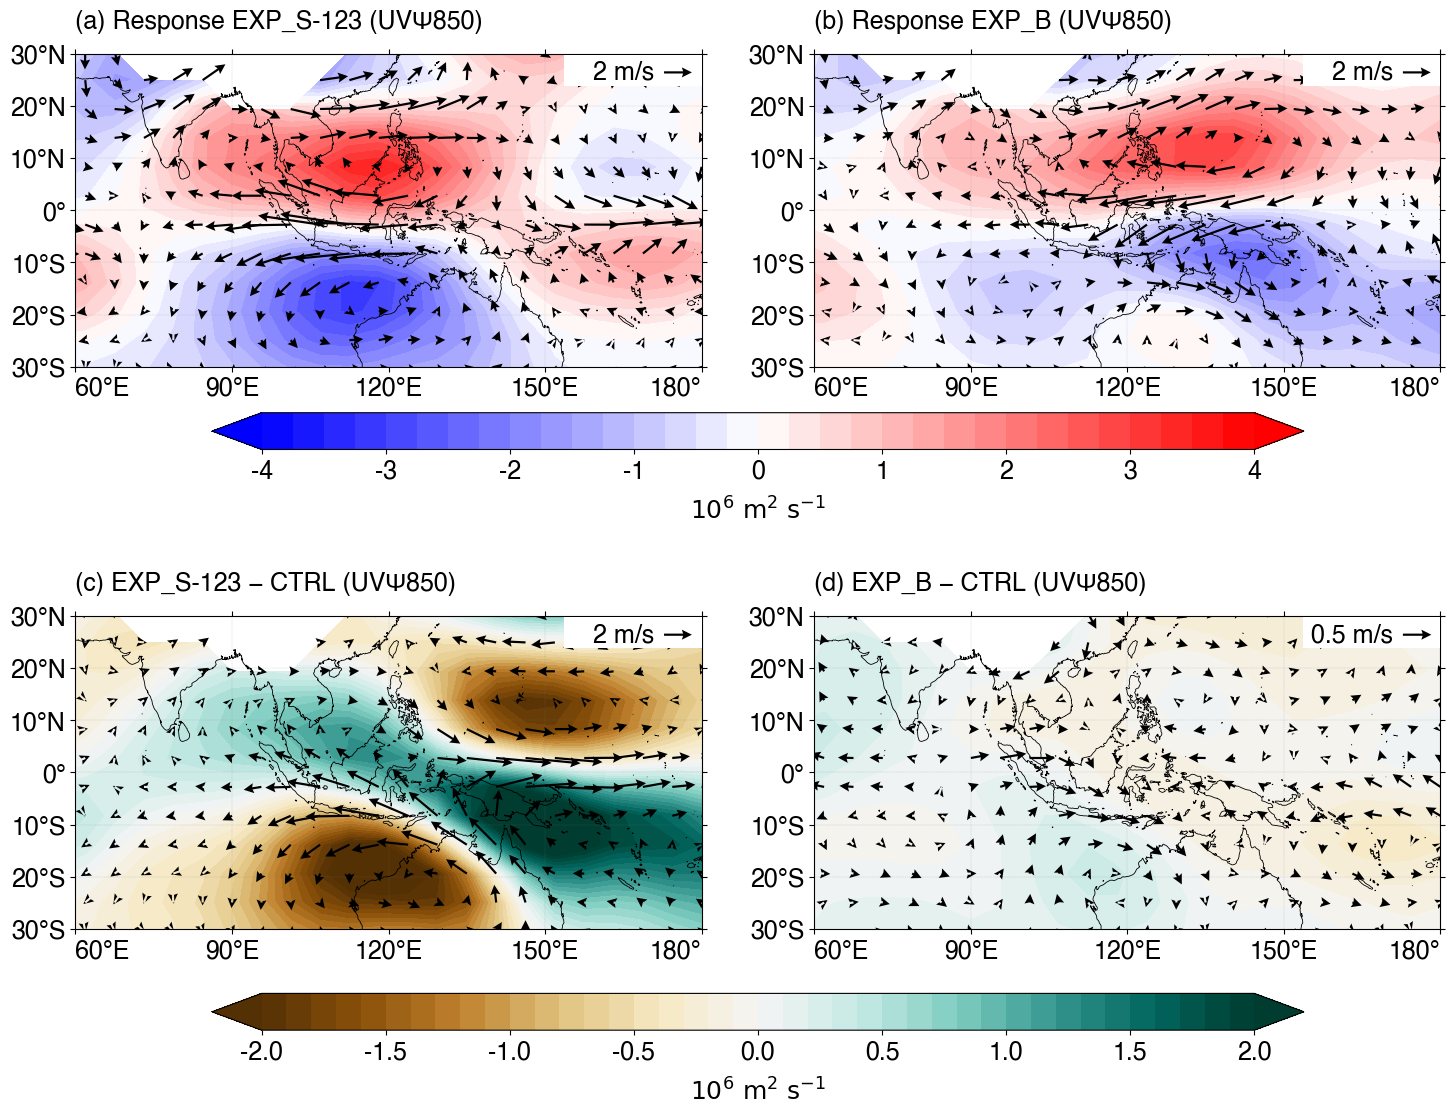

Saved plot to /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig6/fig6a.png


In [4]:
# Use the source scale for absolute responses and the requested scale for changes.
vmin_psi = -4.0
vmax_psi = 4.0
levels_psi = np.arange(-4.0, 4.01, 0.25)
ticks_psi = np.arange(-4.0, 4.1, 1.0)
norm_psi = mcolors.Normalize(vmin=vmin_psi, vmax=vmax_psi)

diff_vmin_psi, diff_vmax_psi = -2.0, 2.0
diff_levels_psi = np.arange(diff_vmin_psi, diff_vmax_psi + 0.01, 0.1)
diff_ticks_psi = np.arange(diff_vmin_psi, diff_vmax_psi + 0.1, 0.5)
diff_norm_psi = mcolors.Normalize(vmin=diff_vmin_psi, vmax=diff_vmax_psi)

# Nice tick formatting function
def format_nice_number(value, pos=None):
    if not np.isfinite(value):
        return ''
    if np.isclose(value, 0.0):
        return '0'
    abs_value = abs(value)
    if abs_value < 1e-2 or abs_value >= 1e4:
        exponent = int(np.floor(np.log10(abs_value)))
        mantissa = value / (10.0 ** exponent)
        if np.isclose(mantissa, round(mantissa), rtol=1e-6, atol=1e-12):
            mantissa_text = f'{mantissa:.0f}'
        else:
            mantissa_text = f'{mantissa:.1f}'.rstrip('0').rstrip('.')
        return f'{mantissa_text}e{exponent}'
    if abs_value >= 100:
        text = f'{value:.0f}'
    elif abs_value >= 10:
        text = f'{value:.1f}'
    elif abs_value >= 1:
        text = f'{value:.2f}'
    else:
        text = f'{value:.3f}'
    return text.rstrip('0').rstrip('.')

# Subplot and font parameters matching revisi styling
PLOT_FONTSIZE = 18
plt.rcParams.update({
    'font.size': PLOT_FONTSIZE,
    'axes.titlesize': PLOT_FONTSIZE,
    'axes.labelsize': PLOT_FONTSIZE,
    'xtick.labelsize': PLOT_FONTSIZE,
    'ytick.labelsize': PLOT_FONTSIZE,
})

# Layout parameters for 2x2 grid matching other subplot panels
fig_width = 15
fig_height = 11.5
subplot_wspace = 0.18
subplot_hspace = 0.68
fig_left = 0.055
fig_right = 0.965
fig_bottom = 0.15
fig_top = 0.93
colorbar_y_gap = 0.075
colorbar_height = 0.032
colorbar_labelpad = 10
streamfunction_cbar_label = r'$10^6\ \mathrm{m}^2\ \mathrm{s}^{-1}$'

# Create figure
fig = plt.figure(figsize=(fig_width, fig_height))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=subplot_hspace, wspace=subplot_wspace)

ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
ax3 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
ax4 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))

subplots = [
    (ax1, data_abs['R3']['psi'], data_abs['R3']['u'], data_abs['R3']['v'], 
     r'(a) Response EXP_S-123 (UVΨ850)', 45, 2, '2 m/s', 0.84),
    (ax2, data_abs['R4']['psi'], data_abs['R4']['u'], data_abs['R4']['v'], 
     r'(b) Response EXP_B (UVΨ850)', 45, 2, '2 m/s', 0.84),
    (ax3, data_diff['R3_minus_R1']['psi'], data_diff['R3_minus_R1']['u'], data_diff['R3_minus_R1']['v'], 
     r'(c) EXP_S-123 − CTRL (UVΨ850)', 45, 2, '2 m/s', 0.84),
    (ax4, data_diff['R4_minus_R1']['psi'], data_diff['R4_minus_R1']['u'], data_diff['R4_minus_R1']['v'], 
     r'(d) EXP_B − CTRL (UVΨ850)', 11, 0.5, '0.5 m/s', 0.84)
]

top_cf = None
diff_cf = None
for ax, psi_da, u_da, v_da, title, scale_val, key_mag, key_label, key_x in subplots:
    # Add cyclic point to avoid the 0/360 boundary gap
    cyclic_psi, cyclic_lon = cutil.add_cyclic_point(psi_da.values, coord=ds.lon.values)
    
    # Plot contourf of streamfunction
    is_difference = ax in [ax3, ax4]
    cf = ax.contourf(cyclic_lon, ds.lat.values, cyclic_psi,
                     levels=diff_levels_psi if is_difference else levels_psi,
                     cmap='BrBG' if is_difference else 'bwr',
                     norm=diff_norm_psi if is_difference else norm_psi,
                     transform=ccrs.PlateCarree(), extend='both')
    if is_difference:
        diff_cf = cf
    else:
        top_cf = cf
    
    # Add 50m high-resolution coastline
    ax.coastlines(resolution='50m', color='black', linewidth=0.6, zorder=3)
    ax.set_extent([60, 180, -30, 30], crs=ccrs.PlateCarree())

    # Set grid ticks and formatting
    xticks = [60, 90, 120, 150, 180]
    yticks = [-30, -20, -10, 0, 10, 20, 30]
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
    ax.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
    ax.tick_params(direction='out', top=True, right=True, labelsize=PLOT_FONTSIZE)
    ax.tick_params(labelright=False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Draw subtle gridlines matching ticks
    ax.gridlines(xlocs=xticks, ylocs=yticks, draw_labels=False, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
    
    # Generate meshgrid for the native quiver density.
    lon_2d, lat_2d = np.meshgrid(ds.lon.values, ds.lat.values)
    
    # scale_val is set in `subplots`: increase it for shorter arrows; decrease it for longer arrows.
    # Increase arrow_width to make arrows thicker; decrease it to make them thinner.
    arrow_width = 0.0035
    head_scale = 0.0020 / arrow_width
    
    # Draw wind vectors
    q = ax.quiver(lon_2d, lat_2d, u_da.values, v_da.values, transform=ccrs.PlateCarree(),
                  color='black', scale=scale_val, alpha=1.0,  # Lower alpha (0-1) makes the plotted arrows more transparent.
                  width=arrow_width,
                  headwidth=8 * head_scale,
                  headlength=8 * head_scale,
                  headaxislength=7 * head_scale,
                  minshaft=0,
                  minlength=0,
                  zorder=4)
    
    # Quiver-key white box: (left, bottom), width, height are axes fractions (0=left/bottom, 1=right/top).
    # Change left/bottom to move the box; change width/height to resize it; alpha controls box opacity.
    key_box = mpatches.Rectangle((0.78, 0.897), 0.22, 0.10, transform=ax.transAxes,
                                facecolor='white', edgecolor='none', alpha=1, zorder=5)
    ax.add_patch(key_box)
    # X/Y move the key within the axes; U (= key_mag) changes the reference-arrow magnitude/length.
    # labelpos='W' keeps the text left of the arrow; labelsep changes text-arrow spacing.
    qk = ax.quiverkey(q, X=0.94, Y=0.94, U=key_mag, label=key_label,
                      labelpos='W', coordinates='axes', fontproperties={'size': PLOT_FONTSIZE}, labelsep=0.1)
    qk.set_zorder(6)
    qk.text.set_zorder(7)
    
    # Subplot Title
    ax.set_title(title, fontsize=PLOT_FONTSIZE, fontweight='bold', loc='left', pad=18)

# Apply figure layout adjustments
fig.subplots_adjust(left=fig_left, right=fig_right, bottom=fig_bottom, top=fig_top)

# Align longitude ticks
fig.canvas.draw()
for ax in [ax1, ax2, ax3, ax4]:
    for label in ax.get_xticklabels():
        text = label.get_text()
        if "60" in text:
            label.set_ha('left')
        elif "180" in text:
            label.set_ha('right')

# Absolute-field colour bar between the top and difference rows.
pos_top_l = ax1.get_position()
pos_top_r = ax2.get_position()
pos_bottom_l = ax3.get_position()
pos_bottom_r = ax4.get_position()

top_total_width = pos_top_r.x1 - pos_top_l.x0
top_cbar_width = 0.80 * top_total_width
top_cbar_x0 = pos_top_l.x0 + (top_total_width - top_cbar_width) / 2
top_gap = pos_top_l.y0 - pos_bottom_l.y1
top_cbar_y0 = pos_top_l.y0 - colorbar_height - 0.040

top_cax = fig.add_axes([top_cbar_x0, top_cbar_y0, top_cbar_width, colorbar_height])
top_cbar = fig.colorbar(top_cf, cax=top_cax, orientation='horizontal', extend='both', ticks=ticks_psi)

# Difference colour bar using the BrBG colormap below the bottom row.
total_width = pos_bottom_r.x1 - pos_bottom_l.x0
diff_cbar_width = 0.80 * total_width
diff_cbar_x0 = pos_bottom_l.x0 + (total_width - diff_cbar_width) / 2
diff_cbar_y0 = pos_bottom_l.y0 - 0.088

diff_cax = fig.add_axes([diff_cbar_x0, diff_cbar_y0, diff_cbar_width, colorbar_height])
diff_cbar = fig.colorbar(diff_cf, cax=diff_cax, orientation='horizontal', extend='both', ticks=diff_ticks_psi)

for _cbar in (top_cbar, diff_cbar):
    _cbar.ax.xaxis.set_major_formatter(FuncFormatter(format_nice_number))
    _cbar.update_ticks()
    _cbar.ax.tick_params(labelsize=PLOT_FONTSIZE)
    _cbar.set_label(streamfunction_cbar_label, fontsize=PLOT_FONTSIZE, labelpad=colorbar_labelpad)


# Save figures to output directory
output_dir = '/Users/rizzie/Work/PaperENSO/Scripts_v2/Fig6'
os.makedirs(output_dir, exist_ok=True)
png_path = os.path.join(output_dir, 'fig6a.png')
plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved plot to {png_path}")
